# 02 — Phase-type basics og sojourn-tider

I denne notebook vil jeg mere på phase-type herunder: Green-matricen, sojourn-tider, og hvad der sker, når man introducerer, populationsstørrelse $N$ som en eksplicit parameter via *update_weights()*.

**Spørgsmål jeg gerne vil undersøge:**

- Hvad fortæller Green-matricen $\mathbf{U} = (-\mathbf{S})^{-1}$ konkret?,
- Hvordan ændrer sojourn-tider sig med $n$ og $N$?
- Hvad sker der, hvis jeg skalerer alle rater med $1/N$ — dvs. indfører, populationsstørrelse som parameter?,
- Kan jeg bruge reward-transformationen til at beregne genetisk diversitet $\pi$?

In [ ]:
from phasic import Graph, with_ipv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%config InlineBackend.figure_format = 'svg'
np.random.seed(42)
sns.set_palette('tab10')
plt.rcParams['figure.dpi'] = 120

## 1. Koalescenten med populationsstørrelse N
    
I standardkoalescenten er alle rater $1$ (tid i enheder af $2N$ generationer).

Nu vil jeg introducerer $N$ eksplicit: raten for $k$ linjer er $\frac{\binom{k}{2}}{N}$. Dette gøres ved at parameterisere kantvægtene med *update_weights()*.

**Strategi:** Kanten for koalescens af linjer $i$ og $j$ får coefficientvektoren, $[state[i]*(state[j]-same)/(1+same), 0]$, og recombinationsraten ville være $[0, R]$ (ikke brugt her). Med parameter $[1/N]$ giver punktproduktet den korrekte rate.


In [5]:
# Parameteriseret koalescent (two_locus_arg_2param)

nr_samples = 4

@with_ipv([nr_samples] + [0] * (nr_samples - 1))
def coalescent_param(state):
    """Koalescent med N som parameter.
    
    Kantvægtene er coefficient-vektorer: [koalescenskoefficient, 0].
    Kaldes med update_weights ([1/N]) for at sætte populationsstørrelsen.
    """
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1;new[i + j + 1] += 1
            coeff = state[i] * (state[j] - same) / (1 + same)
            # coefficent-vektor: [koalescenskoefficient],
            # parameter [1/N] giver rate = ceoff*(1/N) = binom(k,2)/N
            transitions.append((new, [coeff]))
    return transitions

graph_param = Graph(coalescent_param)
print(f"Parametervektor har længde: {graph_param.param_length()}")
# Sæt N=1 (standard: tid i enheder af 2N generationer)
graph_param.update_weights([1.0])
print(f"E[TMRCA] for N=1: {graph_param.expectation():.4f}")
# Sæt N=2 — alle rater halveres, ventetider fordobles
graph_param.update_weights([1/2])
print(f"E[TMRCA] for N=2: {graph_param.expectation():.4f}")
# Sæt N=10
graph_param.update_weights([1/10])
print(f"E[TMRCA] for N=10: {graph_param.expectation():.4f}")

Parametervektor har længde: 1
E[TMRCA] for N=1: 1.5000
E[TMRCA] for N=2: 3.0000
E[TMRCA] for N=10: 15.0000


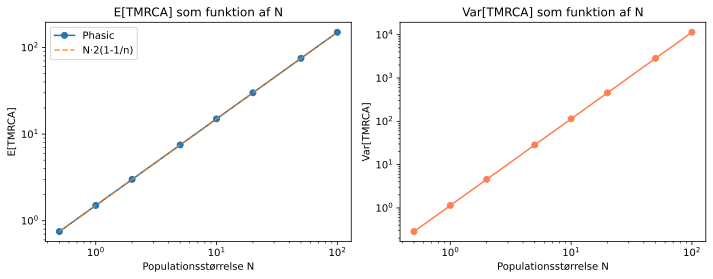

Observation: E[TMRCA] ∝ N (lineær skalering). Var[TMRCA] ∝ N².
CV = std/mean er konstant — formen ændres ikke, kun tidsskalaen.
Coefficient of variation CV for N=[0.5, 1, 2, 5, 10, 20, 50, 100]: ['0.711', '0.711', '0.711', '0.711', '0.711', '0.711', '0.711', '0.711']


In [9]:
# Hvad sker der med E[TMRCA] og Var[TMRCA] som funktion af N?

N_values = [0.5, 1, 2, 5, 10, 20, 50, 100]
E_vals, Var_vals = [], []
for N in N_values:
    graph_param.update_weights([1/N])
    E_vals.append(graph_param.expectation())
    Var_vals.append(graph_param.variance())

# Analytisk: E[TMRCA] = N * 2(1-1/n)
E_ana = [N * 2 * (1 - 1/nr_samples) for N in N_values]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].loglog(N_values, E_vals, 'o-', label='Phasic')
axes[0].loglog(N_values, E_ana, '--', label='N·2(1-1/n)', alpha=0.8)
axes[0].set_xlabel('Populationsstørrelse N')
axes[0].set_ylabel('E[TMRCA]')
axes[0].set_title('E[TMRCA] som funktion af N')
axes[0].legend()
   
axes[1].loglog(N_values, Var_vals, 'o-', color='coral')
axes[1].set_xlabel('Populationsstørrelse N')
axes[1].set_ylabel('Var[TMRCA]')
axes[1].set_title('Var[TMRCA] som funktion af N')
    
plt.tight_layout()
plt.show()
print("Observation: E[TMRCA] ∝ N (lineær skalering). Var[TMRCA] ∝ N².")
print("CV = std/mean er konstant — formen ændres ikke, kun tidsskalaen.")
    
CVs = [np.sqrt(v)/e for e, v in zip(E_vals, Var_vals)]
print(f"Coefficient of variation CV for N={N_values}: {[f'{cv:.3f}' for cv in CVs]}")

## Green-matricen i dybden

Green-matricen $\mathbf{U} = (-\mathbf{S})^{-1}$ er central for forståelsen af "phase-type distributioner. Elementet $U_{ij}$ er den forventede tid brugt, i tilstand $j$, givet at processen startede i tilstand $i$.

For koalescenten: $\alpha \mathbf{U}$ giver sojourn-tiderne for den faktiske startfordeling.

In [ ]:
# Sæt N=1 for klassiske tidsenheder
graph_param.update_weights([1.0])
mats = graph_param.as_matrices()
    
S = mats.sim
alpha = mats.ipv
U = np.linalg.inv(-S)  # Green-matricen
    
state_labels = [str(list(s)) for s in mats.states]
 
print("Green-matricen U = (-S)⁻¹:")
df_U = pd.DataFrame(U, index=state_labels, columns=state_labels)
print(df_U.round(4))
print()
print("Diagonal-elementerne (forventet tid i tilstand j givet start i j):")
for i, (label, u_ii) in enumerate(zip(state_labels, np.diag(U))):
    print(f"Tilstand {label}: {u_ii:.4f} (= 1/|diagonal i S| = 1/{abs(S[i,i]):.1f})")

Green-matricen U = (-S)⁻¹:
                                                    [np.int32(4), np.int32(0), np.int32(0), np.int32(0)]  \
[np.int32(4), np.int32(0), np.int32(0), np.int3...                                             0.1667      
[np.int32(2), np.int32(1), np.int32(0), np.int3...                                             0.0000      
[np.int32(0), np.int32(2), np.int32(0), np.int3...                                             0.0000      
[np.int32(1), np.int32(0), np.int32(1), np.int3...                                             0.0000      

                                                    [np.int32(2), np.int32(1), np.int32(0), np.int32(0)]  \
[np.int32(4), np.int32(0), np.int32(0), np.int3...                                             0.3333      
[np.int32(2), np.int32(1), np.int32(0), np.int3...                                             0.3333      
[np.int32(0), np.int32(2), np.int32(0), np.int3...                                             0.0000      


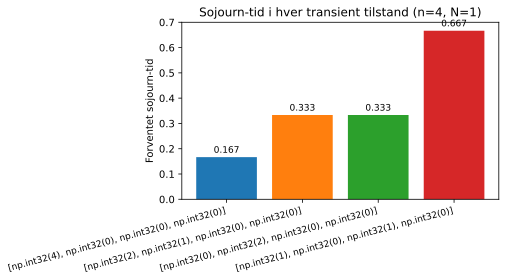

Total sojourn-tid = E[TMRCA] = 1.5000

Fortolkning:
  [4,0,0,0]: 4 singletons. Rate = 6, lav sojourn-tid (0.167).
  [2,1,0,0]: 2 sing + 1 doub. Rate = 3, dobbelt sojourn (0.333).
  [1,0,1,0] og [0,2,0,0]: Rate = 1, tre gange længere sojourn (0.667 + 0.333).


In [11]:
# Sojourn-tider: α·U giver den forventede tid i hver tilstand,
sojourn = alpha @ U

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(range(len(sojourn)), sojourn,
                  color=sns.color_palette('tab10', len(sojourn)))
ax.set_xticks(range(len(sojourn)))
ax.set_xticklabels(state_labels, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Forventet sojourn-tid')
ax.set_title('Sojourn-tid i hver transient tilstand (n=4, N=1)')
  
# Annotér med værdier
for bar, val in zip(bars, sojourn):
  ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)
   
plt.tight_layout()
plt.show()
    
print(f"Total sojourn-tid = E[TMRCA] = {sojourn.sum():.4f}")
print()
print("Fortolkning:")
print("  [4,0,0,0]: 4 singletons. Rate = 6, lav sojourn-tid (0.167).")
print("  [2,1,0,0]: 2 sing + 1 doub. Rate = 3, dobbelt sojourn (0.333).")
print("  [1,0,1,0] og [0,2,0,0]: Rate = 1, tre gange længere sojourn (0.667 + 0.333).")

### Hvad sker der med sojourn-tiderne som funktion af N?
   
**Eksperiment:** Da alle rater skaleres med $1/N$, forventer jeg at sojourn-tiderne skalerer med $N$. Men den relative fordeling af sojourn-tid bør forblive konstant.

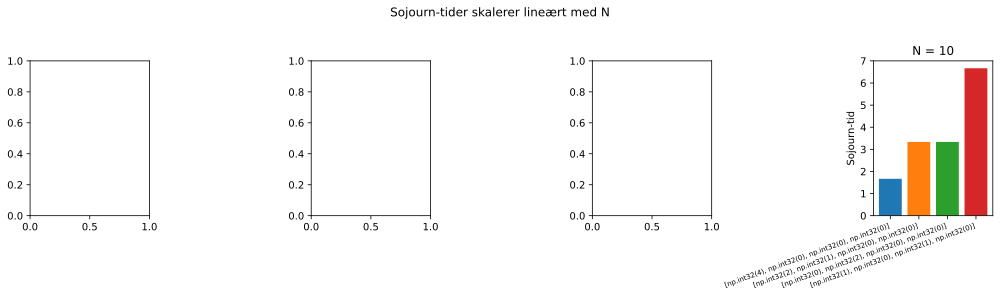

Relativ sojourn-tid (N=1): [0.111 0.222 0.222 0.444]
Relativ sojourn-tid (N=10): [0.111 0.222 0.222 0.444]
→ Identiske, som forventet. N ændrer kun tidsskalaen, ikke fordelingsformen.


In [ ]:
N_test = [0.5, 1, 5, 10]
   
fig, axes = plt.subplots(1, len(N_test), figsize=(14, 4), sharey=False)
    
for ax, N in zip(axes, N_test):
    graph_param.update_weights([1/N])
    sojourn_N = graph_param.expected_sojourn_time()
    # spring tilstand 0 (start) og sidste (absorb) over
    soj_transient = sojourn_N[1:-1]
    labels_t = state_labels  # fra mats ovenfor
    
ax.bar(range(len(labels_t)), soj_transient,
                  color=sns.color_palette('tab10', len(labels_t)))
ax.set_xticks(range(len(labels_t)))
ax.set_xticklabels(labels_t, rotation=20, ha='right', fontsize=7)
ax.set_title(f'N = {N}')
ax.set_ylabel('Sojourn-tid')

plt.suptitle('Sojourn-tider skalerer lineært med N', y=1.02)
plt.tight_layout()
plt.show()
   
# Verificer relativ fordeling er konstant
graph_param.update_weights([1.0])
soj_1 = np.array(graph_param.expected_sojourn_time()[1:-1])
graph_param.update_weights([1/10])
soj_10 = np.array(graph_param.expected_sojourn_time()[1:-1])
print("Relativ sojourn-tid (N=1):", np.round(soj_1 / soj_1.sum(), 3))
print("Relativ sojourn-tid (N=10):", np.round(soj_10 / soj_10.sum(), 3))
print("→ Identiske, som forventet. N ændrer kun tidsskalaen, ikke fordelingsformen.")


## 4. Genetisk diversitet π og TMRCA-sammenhæng

Den forventede nukleotiddiversitet $\pi$ (sandsynlighed for, at to tilfældige sekvenser adskiller sig på et givet site) er:
$$
\pi = \theta \cdot \mathbb{E}[T_2] = \theta \cdot \frac{2}{1} = 2\theta,
$$
    
fordi med to linjer er ventetiden til koalescens $T_2 \sim \text{Exp}(1)$ med $\mathbb{E}[T_2] = 1$ (i enheder af $2N$), og mutationsrate er $\theta = 4Nu$.
Jeg kan beregne dette direkte via phasic for et par af sekvenser.

**Eksperiment:** Beregn $\mathbb{E}[T_2]$ og verifiker at $\pi = \theta$ for $n=2$.

In [22]:
# Koalescent for n=2 (det simpleste tilfælde)
@with_ipv([2, 0])
def coalescent_2(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1; new[i + j + 1] += 1
            transitions.append((new, [state[i] * (state[j] - same) / (1 + same)]))
    return transitions

g2 = Graph(coalescent_2)

#Sæt N (total populationsstørrelse, diploid = 2*Ne)
Ne = 10_000  # effektiv populationsstørrelse
g2.update_weights([1 / Ne])
    
# TMRCA for et par (= T2)
E_T2 = g2.expectation()
u = 1e-8  # mutationsrate per site per generation
theta = 4 * Ne * u  # skaleret mutationsrate
pi_forventet = theta  # for n=2: pi = theta * E[T2] = theta * 1 (i enheder 2N gen)
print(f"Effektiv populationsstørrelse Ne = {Ne:,}")
print(f"Mutationsrate u = {u:.1e} per site per generation")
print(f"θ = 4·Ne·u = {theta:.4f}")
print(f"E[T2] (i generationer) = {E_T2:.0f}")
print(f"\nForventet genetisk diversitet π = θ·E[T2]/(2N) = {theta:.4f}")
print(f"(E[T2] er her i enheder af generationer, θ er per site)")

Effektiv populationsstørrelse Ne = 10,000
Mutationsrate u = 1.0e-08 per site per generation
θ = 4·Ne·u = 0.0004
E[T2] (i generationer) = 10000

Forventet genetisk diversitet π = θ·E[T2]/(2N) = 0.0004
(E[T2] er her i enheder af generationer, θ er per site)


### 5. Hvad sker der med fordelingen, hvis man ændrer n og N samtidig?
    
**Eksperiment:** Jeg holder $\theta = 4Nu$ konstant men varierer $N$ og $n$ separat. Hvad dominerer TMRCA-fordelingens form?

In [23]:
# Konstant θ scenario: varier N og n
theta_fixed = 2.0
u_fixed = 1e-8

scenarios = [
    {'n': 4,  'N': theta_fixed / (4 * u_fixed), 'label': 'n=4, N=50M'},
    {'n': 8,  'N': theta_fixed / (4 * u_fixed), 'label': 'n=8, N=50M'},
    {'n': 4,  'N': 2 * theta_fixed / (4 * u_fixed), 'label': 'n=4, N=100M'},
]
    
t_plot = np.linspace(0, 3e8, 500)  # i generationer

fig, ax=plt.subplots(figsize=(8,1))
for s in scenarios:
    n,N = s['n'], s['N']

@with_ipv([n] + [0] * (n - 1))
def coal_scenario(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1; new[i + j + 1] += 1
            transitions.append((new, [state[i] * (state[j] - same) / (1 + same)]))
    return transitions

g = Graph(coal_scenario)
g.update_weights([1/N])
ax.plot(t_plot / 1e6, g.pdf(t_plot), label=s['label'], lw=1.8)

ax.set_xlabel('TMRCA (millioner generationer)')
ax.set_ylabel('Tæthed')
ax.set_title('PDF for TMRCA: effekten af n og N')
ax.legend()
plt.tight_layout()
plt.show()

print("Observation:")
print("- Fordobling af N forskyder fordelingen proportionalt til højre.")
print("- Fordobling af n skarpstiller den tidlige del men ændrer ikke halens position.")


: 

## 6. Reward-baseret verifikation: E[T_total] og Watterson's θ

Watterson's estimator er $\hat{\\theta}_W = S / a_n$, hvor $S$ er antallet af, segregerende sider og $a_n = \sum_{k=1}^{n-1} 1/k$. Jeg kan verificere at $\mathbb{E}[S] = \theta \cdot a_n$ via reward-transformationen."
 

In [ ]:
# Byg standard n=4 koalescent,

graph_param.update_weights([1.0])  # N=1 (standardtid)
    
# Total grenlængde E[T_total] via rewards,
rmat = graph_param.states().T

# Reward r_total = antal linjer i alt = sum(state),
r_total = np.sum(graph_param.states(), axis=1)
E_T_total = graph_param.expectation(r_total)
    
# Analytisk: E[T_total] = 2 * sum(1/k, k=1..n-1),
a_n = sum(1/k for k in range(1, nr_samples))
E_T_total_ana = 2 * a_n

print(f"E[T_total] via phasic rewards: {E_T_total:.6f}")
print(f"E[T_total] analytisk (2·aₙ):   {E_T_total_ana:.6f}")
print(f"aₙ = Σ 1/k (k=1..{nr_samples-1}) = {a_n:.4f}")
print()
    
theta_test = 2.0
E_S = theta_test * E_T_total / 2  # E[S] = (θ/2) * E[T_total],
print(f"Forventet antal segregerende sider for θ={theta_test}: E[S] = {E_S:.4f}")
print(f"Analytisk: E[S] = θ·aₙ = {theta_test * a_n:.4f}")

In [ ]:
# Sammenlign sojourn-tider og grenlængder i en samlet figur

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    
# Sojourn-tid per linje-type
sojourn_by_type = [graph_param.expectation(r) for r in rmat]
labels_t = [f'{i+1}-ton' for i in range(nr_samples)]
    
axes[0].bar(labels_t, sojourn_by_type, color=sns.color_palette('tab10', nr_samples))
axes[0].set_ylabel('E[grenlængde]')
axes[0].set_title('Forventet grenlængde pr. linje-type (n=4)')
for i, v in enumerate(sojourn_by_type):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)
    
# Kumuleret grenlængde over n
n_vals = list(range(2, 13))
E_T_totals = []
for n in n_vals:
    @with_ipv([n] + [0] * (n - 1))
    def coal_tot(state):
        transitions = []
        for i in range(state.size):
            for j in range(i, state.size):
                same = int(i == j)
                if same and state[i] < 2: continue
                if not same and (state[i] < 1 or state[j] < 1): continue
                new = state.copy()
                new[i] -= 1; new[j] -= 1; new[i + j + 1] += 1
                transitions.append((new, state[i] * (state[j] - same) / (1 + same)))
        return transitions
   
    g = Graph(coal_tot)
    r_tot = np.sum(g.states(), axis=1)
    E_T_totals.append(g.expectation(r_tot))
    
E_T_analytisk = [2 * sum(1/k for k in range(1, n)) for n in n_vals]
    
axes[1].plot(n_vals, E_T_totals, 'o-', label='Phasic')
axes[1].plot(n_vals, E_T_analytisk, '--', label='2·Σ(1/k)', alpha=0.8)
axes[1].set_xlabel('n')
axes[1].set_ylabel('E[T_total]')
axes[1].set_title('Total grenlængde som funktion af n')
axes[1].legend()
    
plt.tight_layout()
plt.show()
print("Observation: E[T_total] vokser logaritmisk med n — hurtige gevinster ved")
print("stigende n, men med aftagende afkast.")

## Diskret phase-type: antal segregerende sider S

Antallet af segregerende sider $S$ er diskret PH-distribueret. Jeg kan beregne dens PMF via *discretize()* og *reward_transform()*.

In [ ]:
# Byg n=4 koalescent med mutations-parameter\n",
nr_samples = 4

@with_ipv([nr_samples] + [0] * (nr_samples - 1))
def coalescent_mut(state):
    """Koalescent parameteriseret med [1/N, theta/2].
    
    Kanten for koalescens: [koalescenskoeff, 0]
    Koefficient for mutations-reward: [0, 1] per aktiv linje
    """
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1; new[i + j + 1] += 1
            coeff = state[i] * (state[j] - same) / (1 + same)
            transitions.append((new, [coeff, 0]))
    return transitions
    
mutation_graph = Graph(coalescent_mut)
    
# Mutations-reward: antal aktive linjer i tilstanden

def mutation_rate_fn(state):
    nr_lineages = sum(state)
    return [0, nr_lineages] # coefficient-vektor: [0 for coal, nr_lineages for mut]
    
mutation_graph = mutation_graph.discretize(mutation_rate_fn)
rewards = mutation_graph.rewards
    
# Sæt parametre: [1/N, theta/2]
theta = 2.0
mutation_graph.update_weights([1.0, theta / 2])
    
rt_graph = mutation_graph.reward_transform(rewards)
    
# PMF for S
k_values = np.arange(0, 15)
pmf = rt_graph.pdf(k_values)
    
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(k_values, pmf, alpha=0.8)
ax.set_xlabel('Antal segregerende sider S')
ax.set_ylabel('Sandsynlighed')
ax.set_title(f'PMF for S (n={nr_samples}, θ={theta})')
    
E_S_phasic = rt_graph.expectation()\
E_S_analytisk = theta * sum(1/k for k in range(1, nr_samples))
ax.axvline(E_S_phasic, color='red', linestyle='--', label=f'E[S]={E_S_phasic:.2f}')
ax.legend()
plt.tight_layout()
plt.show()
  
print(f"E[S] via phasic:   {E_S_phasic:.4f}")
print(f"E[S] analytisk:    {E_S_analytisk:.4f}  (= θ·aₙ = {theta}·{a_n:.4f})")

In [ ]:
# Hvad sker der med PMF for S når theta varierer?
theta_values = [0.5, 1.0, 2.0, 5.0, 10.0]
    
fig, ax = plt.subplots(figsize=(9, 5))
    
for theta_v in theta_values:
    mutation_graph.update_weights([1.0, theta_v / 2])
    rt_g = mutation_graph.reward_transform(rewards)
    pmf_v = rt_g.pdf(k_values)
    ax.plot(k_values, pmf_v, 'o-', ms=4, lw=1.5, label=f'θ={theta_v}')

ax.set_xlabel('Antal segregerende sider S')
ax.set_ylabel('Sandsynlighed')
ax.set_title('PMF for S for varierende θ (n=4)')
ax.legend(title='θ')
plt.tight_layout()
plt.show()

print("Observation: Større θ → fordelingen skubbes mod højre og bredes ud.")
print("For meget lille θ er P(S=0) ≈ 1 (ingen mutation observeres")

## Opsummering
   
| Eksperiment | Observation |
|---|---|
| E[TMRCA] vs N | Lineær skalering; Var ~ N²; CV konstant |
| Green-matricen U | Diagonal = 1/rate; off-diagonal = videre-tid |
| Sojourn-tider vs N | Skalerer med N, relativ fordeling uændret |
| E[T_total] vs n | Logaritmisk vækst — aftagende afkast |
| PMF for S vs θ | Fordelingen rykker og bredes for større θ |
    
**Næste notebook:** 03_two_island_model.ipynb — migration og struktureret koalescent.